In [1]:
import os
import sys
import rootutils
import pandas as pd
import numpy as np

# Setup the project root indicator
root = rootutils.setup_root(search_from=os.getcwd(), indicator=".project-root", pythonpath=True)
print(f"Project root located at: {root}")

Project root located at: C:\Users\ashre\Documents\lemurs-modeling


In [2]:
# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Classifiers (For Classification Sweeps) ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# --- Regressors (For Regression Sweeps) ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR

# --- Common Non-Sklearn Additions for Sweeps ---
# (Uncomment if needed, usually essential for a modern sweep)
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

In [3]:
from src.utils.database_service import DatabaseService
from dotenv import load_dotenv

# Load environment variables (.env)
load_dotenv()

# Initialize and connect
db = DatabaseService()
if db.connect():
    print("Successfully connected to the database!")
    # Extract a small sample from the proximity table
    proximity_df = db.extract_from_database("proximity")
    print(f"Proximity dataframe shape: {proximity_df.shape}")
    print("\nFirst few rows of raw Proximity (Bluetooth scan) data:")
    display(proximity_df.head())
    db.disconnect()
else:
    print("Database connection failed. Check your .env file.")

Successfully connected to the database!
Proximity dataframe shape: (16004, 4)

First few rows of raw Proximity (Bluetooth scan) data:


,id,app_user_id,number_of_devices,timestamp
0,1,2,38,2025-11-06 15:45:22.193
1,2,2,38,2025-11-06 15:45:22.193
2,3,5,48,2025-11-14 16:39:43.013
3,4,5,48,2025-11-14 16:39:43.013
4,5,5,36,2025-11-15 10:15:19.344


In [4]:
def preprocess_proximity(df: pd.DataFrame) -> pd.DataFrame:
    """Preprocesses raw Proximity (Bluetooth Scan) data.
    
    Args:
        df: Raw DataFrame from proximity table.
    Returns:
        Cleaned DataFrame satisfying the DataModule contract.
    """
    # 1. Rename 'timestamp' to 'start_timestamp' to satisfy the DataModule contract
    df = df.rename(columns={"timestamp": "start_timestamp"})
    
    # 2. Filter out invalid/negative device counts
    df = df[df["number_of_devices"] >= 0].copy()

    # 3. DO ANY OTHER DATA PROCESSING/CLEANING STEPS HERE (REMOVE DUPLICATES, IMPUTE VALUES, ETC)
    df = df.drop_duplicates()
    
    return df

# Verify the preprocessor locally
db.connect()
raw_df = db.extract_from_database("proximity")
db.disconnect()

cleaned_df = preprocess_proximity(raw_df)
print("Columns after preprocessing:", list(cleaned_df.columns))
display(cleaned_df.head())

Columns after preprocessing: ['id', 'app_user_id', 'number_of_devices', 'start_timestamp']


,id,app_user_id,number_of_devices,start_timestamp
0,1,2,38,2025-11-06 15:45:22.193
1,2,2,38,2025-11-06 15:45:22.193
2,3,5,48,2025-11-14 16:39:43.013
3,4,5,48,2025-11-14 16:39:43.013
4,5,5,36,2025-11-15 10:15:19.344


In [28]:
from src.data.components.label_aggregators import MeanAggregator
from src.data.components.samplers import RollingSampler
from sklearn.preprocessing import StandardScaler

# Aggregator: averages survey answers for questions 2 and 3, and binarizes with a threshold of 2.0
aggregator = MeanAggregator(question_ids=[2, 3], threshold=2.0)

# Sampler: 24-hour lookback window with hourly resampling
sampler = RollingSampler(lookback_hours=12.0, resample_freq="1h")

# Scaler: standard scaler
scaler = StandardScaler()

In [29]:
from src.data.health_datamodule import HealthDataModule

# Register modalities, columns, and preprocessors
# Note: 'proximity' is mapped to database column 'number_of_devices'
modalities = ["proximity"]
modality_cols = {"proximity": "number_of_devices"}
preprocessors = {"proximity": preprocess_proximity}

datamodule = HealthDataModule(
    aggregator=aggregator,
    sampler=sampler,
    scaler=scaler,
    preprocessors=preprocessors,
    modalities=modalities,
    batch_size=8,
    split_mode="user",               # Disjoint populations (no user leakage between splits)
    train_val_test_split=(0.7, 0.15, 0.15),
    random_state=42
)

# Trigger setup to fetch, preprocess, split, and scale data
datamodule.setup()

print("✅ DataModule setup completed successfully!")
print(f"Train samples: {len(datamodule.data_train)}")
print(f"Val samples:   {len(datamodule.data_val)}")
print(f"Test samples:  {len(datamodule.data_test)}")

Filtering out 80 duplicate survey responses submitted within 10 minutes with identical answers.
Collapsed 2048 survey responses into 1084 unique daily samples per user.


✅ DataModule setup completed successfully!
Train samples: 728
Val samples:   156
Test samples:  193


In [30]:
# Converting dataloader to dataframe for ML pipelines
def convert_dataloader(dataloader):
    rows = []
    for batch in dataloader:
        X = batch[0]              # shape (bs, 1)
        y = batch[1].item()       # scalar label for entire batch

        # Convert features to Python lists
        X = X.tolist()

        # Broadcast label across all samples
        for xi in X:
            rows.append({
                "feature": xi[0],   # since xi = [value]
                "label": y
            })
    
    df = pd.DataFrame(rows)
    return(df)

train, val, test = convert_dataloader(datamodule.data_train), convert_dataloader(datamodule.data_val), convert_dataloader(datamodule.data_test)

In [31]:
X_train = np.array(train["feature"]).reshape(-1, 1)
y_train = train["label"].values

X_val = np.array(val["feature"]).reshape(-1, 1)
y_val = val["label"].values

X_test = np.array(test["feature"]).reshape(-1, 1)
y_test = test["label"].values

      Metric  Value
0   Accuracy    1.0
1  Precision    0.0
2     Recall    0.0
3   F1 Score    0.0


c:\Users\ashre\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ashre\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ashre\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1495: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(


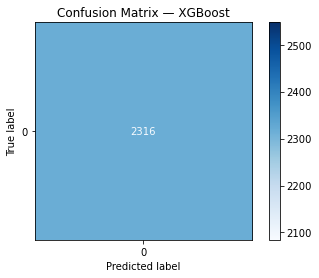

In [32]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    tree_method="hist"
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='binary')
rec  = recall_score(y_test, y_pred, average='binary')
f1   = f1_score(y_test, y_pred, average='binary')
cm   = confusion_matrix(y_test, y_pred)

# Display
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value":  [acc, prec, rec, f1]
})

print(results)

import matplotlib.pyplot as plt
# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format='d')

plt.title("Confusion Matrix — XGBoost")
plt.show()
